In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

df = pd.read_csv('../data/raw/application_train.csv')

print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Description of Application table

In [3]:
home_credit_columns_description = pd.read_csv('../data/raw/HomeCredit_columns_description.csv', encoding='cp1252')

with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(home_credit_columns_description[home_credit_columns_description['Table'] == 'application_{train|test}.csv'][['Row', 'Description']])

,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
5,FLAG_OWN_REALTY,Flag if client owns a house or flat
6,CNT_CHILDREN,Number of children the client has
7,AMT_INCOME_TOTAL,Income of the client
8,AMT_CREDIT,Credit amount of the loan
9,AMT_ANNUITY,Loan annuity


TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


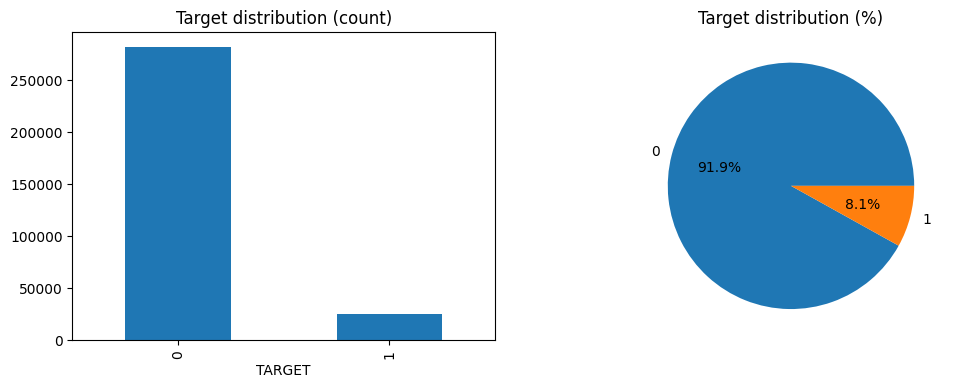

In [ ]:
# Target distribution
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct)

# Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=ax[0])
ax[0].set_title('Target distribution (count)')

target_pct.plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Target distribution (%)')
plt.show()

## Missing values analysis


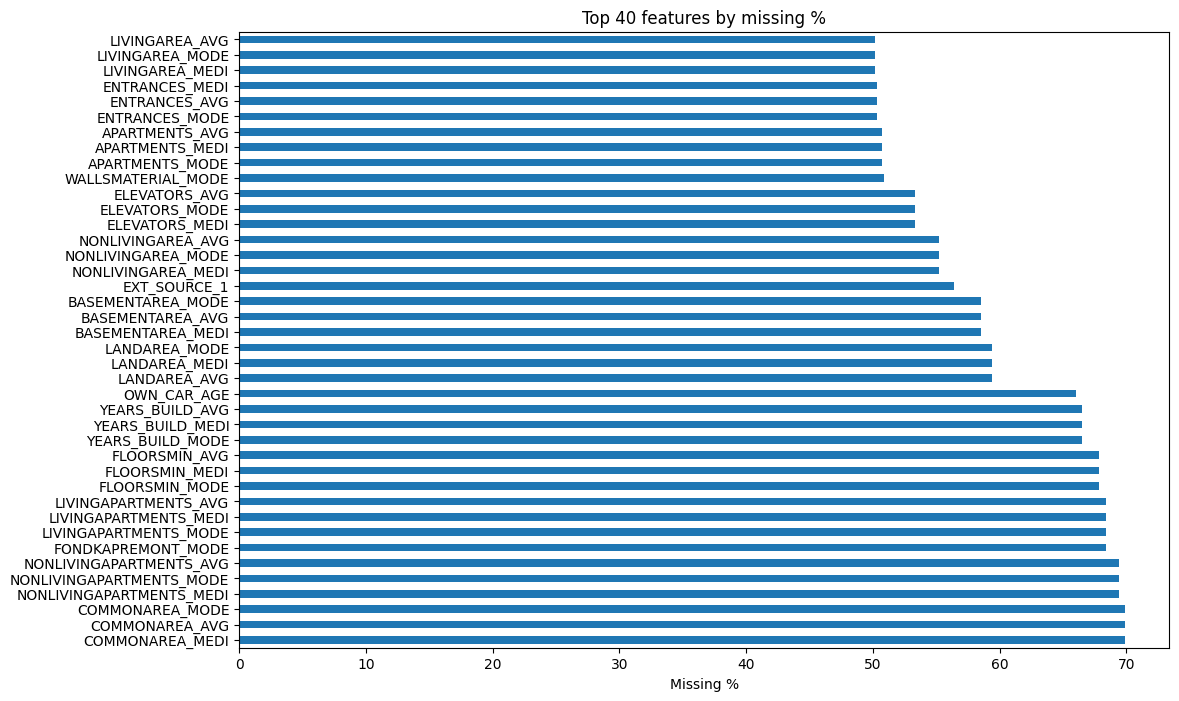

Пропуски > 50%: 41 признаков
Пропуски 20-50%: 9 признаков
Пропуски < 20%: 17 признаков


In [ ]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
missing.head(40).plot(kind='barh')
plt.title('Top 40 features by missing %')
plt.xlabel('Missing %')
plt.show()

# Summary of missing values
print("Пропуски > 50%:", (missing > 50).sum(), "признаков")
print("Пропуски 20-50%:", ((missing > 20) & (missing <= 50)).sum(), "признаков")
print("Пропуски < 20%:", (missing <= 20).sum(), "признаков")

## Numerical features analysis


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['TARGET', 'SK_ID_CURR']]

# base stats
df[num_cols].describe().T

# top features by correlation with a target 
correlations = df[num_cols].corrwith(df['TARGET']).abs().sort_values(ascending=False)
print(correlations.head(20))

EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
FLOORSMAX_MODE                 0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE                0.039645
OWN_CAR_AGE                    0.037612
REGION_POPULATION_RELATIVE     0.037227
dtype: float64


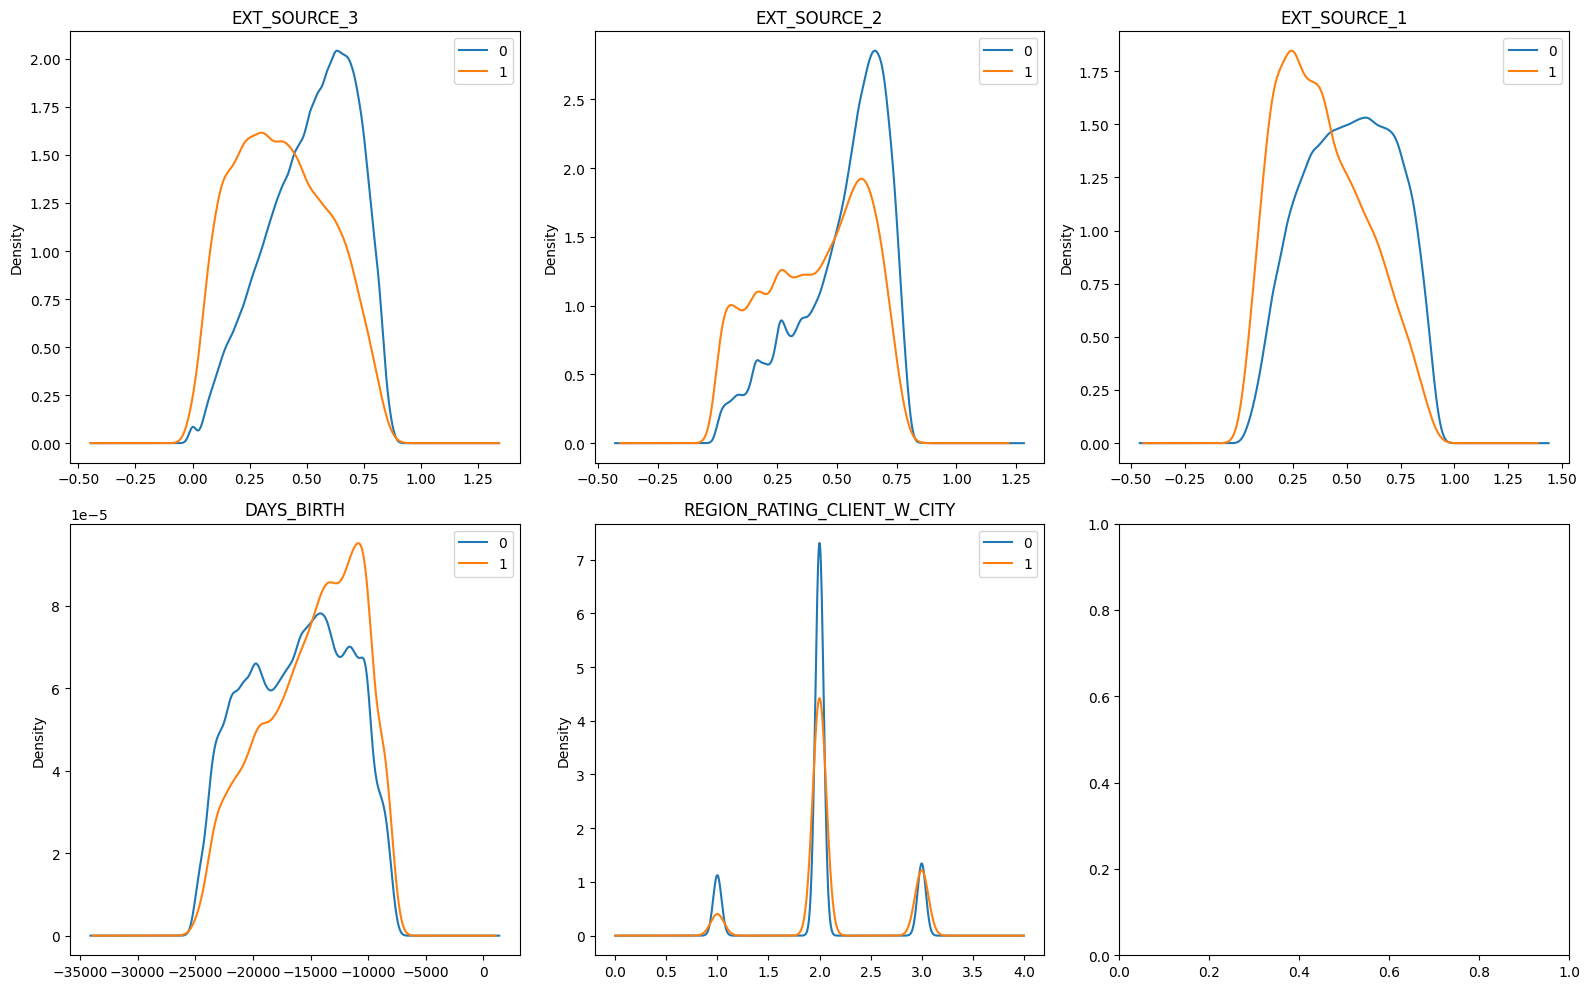

In [ ]:
# TOP 6 FEATURES
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(top_features):
    ax = axes[i//3][i%3]
    df.groupby('TARGET')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Categorical features analysis


In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features: {len(cat_cols)}")

# Default rate по каждой категории
for col in cat_cols:
    dr = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    print(f"\n{dr}:")

/var/folders/vc/zgch74_n23sckf5dm03_fq380000gn/T/ipykernel_5667/682485780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Categorical features: 16

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64:

CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000
Name: TARGET, dtype: float64:

FLAG_OWN_CAR
N    0.085002
Y    0.072437
Name: TARGET, dtype: float64:

FLAG_OWN_REALTY
N    0.083249
Y    0.079616
Name: TARGET, dtype: float64:

NAME_TYPE_SUITE
Other_B            0.098305
Other_A            0.087760
Group of people    0.084871
Unaccompanied      0.081830
Spouse, partner    0.078716
Family             0.074946
Children           0.073768
Name: TARGET, dtype: float64:

NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64:

NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / s

## Statistical test 

In [12]:
# For numerical features — Mann-Whitney U test (non-normal distribution)
results = []
for col in num_cols:
    group0 = df[df['TARGET']==0][col].dropna()
    group1 = df[df['TARGET']==1][col].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    results.append({'feature': col, 'p_value': p, 'significant': p < 0.05})

stat_df = pd.DataFrame(results).sort_values('p_value')
print(f"Significant numerical features: {stat_df['significant'].sum()}")

# For categorical features — Chi-Square test
for col in cat_cols:
    ct = pd.crosstab(df[col], df['TARGET'])
    chi2, p, _ , _ = chi2_contingency(ct)
    print(f"{col}: p={p:.4f} — {' --->  significant' if p < 0.05 else ' #### not significant'}")

Significant numerical features: 86
NAME_CONTRACT_TYPE: p=0.0000 —  --->  significant
CODE_GENDER: p=0.0000 —  --->  significant
FLAG_OWN_CAR: p=0.0000 —  --->  significant
FLAG_OWN_REALTY: p=0.0007 —  --->  significant
NAME_TYPE_SUITE: p=0.0000 —  --->  significant
NAME_INCOME_TYPE: p=0.0000 —  --->  significant
NAME_EDUCATION_TYPE: p=0.0000 —  --->  significant
NAME_FAMILY_STATUS: p=0.0000 —  --->  significant
NAME_HOUSING_TYPE: p=0.0000 —  --->  significant
OCCUPATION_TYPE: p=0.0000 —  --->  significant
WEEKDAY_APPR_PROCESS_START: p=0.0174 —  --->  significant
ORGANIZATION_TYPE: p=0.0000 —  --->  significant
FONDKAPREMONT_MODE: p=0.0008 —  --->  significant
HOUSETYPE_MODE: p=0.0000 —  --->  significant
WALLSMATERIAL_MODE: p=0.0000 —  --->  significant
EMERGENCYSTATE_MODE: p=0.0000 —  --->  significant


## IQR Outliers analysis

In [ ]:
# IQR method for outliers in top features 
for col in top_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

EXT_SOURCE_3: 0 outliers (0.0%)
EXT_SOURCE_2: 0 outliers (0.0%)
EXT_SOURCE_1: 0 outliers (0.0%)
DAYS_BIRTH: 0 outliers (0.0%)
REGION_RATING_CLIENT_W_CITY: 78027 outliers (25.4%)
REGION_RATING_CLIENT: 80527 outliers (26.2%)


## EDA Summary — application_train.csv

### 1. Class Imbalance
The dataset is highly imbalanced: only **8% of applicants defaulted** (TARGET=1), 
while 92% repaid successfully (TARGET=0). This means accuracy is a misleading metric — 
a model predicting "no default" for everyone would achieve 92% accuracy while being 
completely useless. **ROC-AUC and KS statistic** will be used as primary evaluation 
metrics. Class imbalance will be addressed at the modelling stage (class_weight='balanced' 
or scale_pos_weight in LightGBM).

### 2. Most Predictive Numerical Features (by correlation with TARGET)
| Feature | Correlation |
|---|---|
| EXT_SOURCE_3 | 0.179 |
| EXT_SOURCE_2 | 0.160 |
| EXT_SOURCE_1 | 0.155 |
| DAYS_BIRTH | 0.078 |
| REGION_RATING_CLIENT_W_CITY | 0.061 |

The top 3 features are external credit scores (EXT_SOURCE_1/2/3) — normalized 
third-party credit bureau scores. Their strong signal suggests that bureau data 
will be critical in feature engineering (notebook 03). DAYS_BIRTH indicates that 
older applicants tend to default less, which aligns with real-world credit risk 
intuition.

### 3. Missing Values
**41 features have more than 50% missing values.** These will be candidates for 
dropping during feature selection (notebook 04), unless WoE/IV analysis reveals 
strong predictive power despite missingness. Features with 20–50% missing will 
be imputed using median (numerical) or mode (categorical) strategies.

### 4. Significant Categorical Features
All 16 categorical features passed the Chi-Square test at p < 0.05, confirming 
statistically significant association with the default target. Key features include:
- **CODE_GENDER, NAME_EDUCATION_TYPE, NAME_INCOME_TYPE** — classic credit risk 
  segmentation variables used in retail banking scorecards
- **OCCUPATION_TYPE, ORGANIZATION_TYPE** — employment-related features that 
  capture income stability
- **EMERGENCYSTATE_MODE, WALLSMATERIAL_MODE** — property condition features, 
  likely correlated with collateral quality

All categorical features will be encoded via **WoE transformation** in notebook 04, 
preserving their monotonic relationship with the default rate.

